In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from modules.finance.exploration import *

plt.rcParams.update({"font.size": 14})
pd.set_option("display.max_columns", None)

In [2]:
# Configuration
DATA_DIR = "./data/"
OUTPUT_DIR = "./data/fm_prelim/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Files
FINANCIAL_PANEL_FILE = DATA_DIR + "financial_returns_and_controls.parquet"
EPI_DATA_FILE = DATA_DIR + "epi_data_all_lownull.json"

# Parameters
ROLLING_WINDOW = 14
MAX_LAG = 10
IC = 'aic'
ALPHA = 0.05
CORRECTION_METHOD = 'fdr_bh'

print("✓ Configuration complete")

✓ Configuration complete


## Load Data

In [3]:
# Load data
df_returns = pd.read_parquet(FINANCIAL_PANEL_FILE)
df_epi = pd.read_json(EPI_DATA_FILE)
df_epi['date'] = pd.to_datetime(df_epi['date'])
df_epi = df_epi.set_index('date')

df = df_returns.join(df_epi, how='left')
df[df_epi.columns] = df[df_epi.columns].fillna(0)

print(f"Data loaded: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")

Data loaded: (104, 127)
Date range: 2025-01-07 00:00:00 to 2025-05-30 00:00:00


In [4]:
# Find Intensity and Split variants
intensity_variants = find_index_variants(df.columns, 'intensity')
split_col = 'split' if 'split' in df.columns else None

# Combine intensity and split
all_variants = intensity_variants + ([split_col] if split_col else [])

ASSET_COLS = ['r_btc', 'r_gold', 'r_spx']
ASSET_COLS = [c for c in ASSET_COLS if c in df.columns]

print(f"\nIntensity variants found: {len(intensity_variants)}")
for i, var in enumerate(intensity_variants, 1):
    print(f"  {i}. {var}")
if split_col:
    print(f"\nSplit index found: {split_col}")
print(f"\nTotal indices to analyze: {len(all_variants)}")
print(f"\nAssets: {ASSET_COLS}")


Intensity variants found: 4
  1. intensity
  2. intensity_engweighted
  3. intensity_topicweighted
  4. intensity_engweighted_topicweighted

Split index found: split

Total indices to analyze: 5

Assets: ['r_btc', 'r_gold', 'r_spx']


## Descriptive Statistics


Descriptive Statistics

Intensity & Split Indices


,count,mean,std,min,25%,50%,75%,max,skew,kurt,missing_pct,zero_pct
intensity,104.0,0.274019,0.103965,0.003748,0.203703,0.275499,0.335452,0.660202,0.621618,2.512171,0.0,0.000000
intensity_engweighted,104.0,0.282832,0.107840,0.003748,0.218088,0.283616,0.346299,0.660202,0.369188,1.888180,0.0,0.000000
intensity_engweighted_topicweighted,104.0,0.082363,0.062404,0.000000,0.035104,0.071357,0.130662,0.264471,0.574038,-0.375489,0.0,6.730769
intensity_topicweighted,104.0,0.231540,0.085952,0.000000,0.188384,0.246076,0.275559,0.406515,-0.850359,1.180835,0.0,4.807692
split,104.0,0.884275,0.052792,0.738467,0.855158,0.887191,0.916017,0.999944,-0.163404,0.309299,0.0,0.000000



Correlation between variants:


,intensity,intensity_engweighted,intensity_topicweighted,intensity_engweighted_topicweighted,split
intensity,1.000000,0.976642,0.588113,0.401462,-0.360732
intensity_engweighted,0.976642,1.000000,0.607385,0.395185,-0.394212
intensity_topicweighted,0.588113,0.607385,1.000000,0.770144,-0.336394
intensity_engweighted_topicweighted,0.401462,0.395185,0.770144,1.000000,0.155982
split,-0.360732,-0.394212,-0.336394,0.155982,1.000000


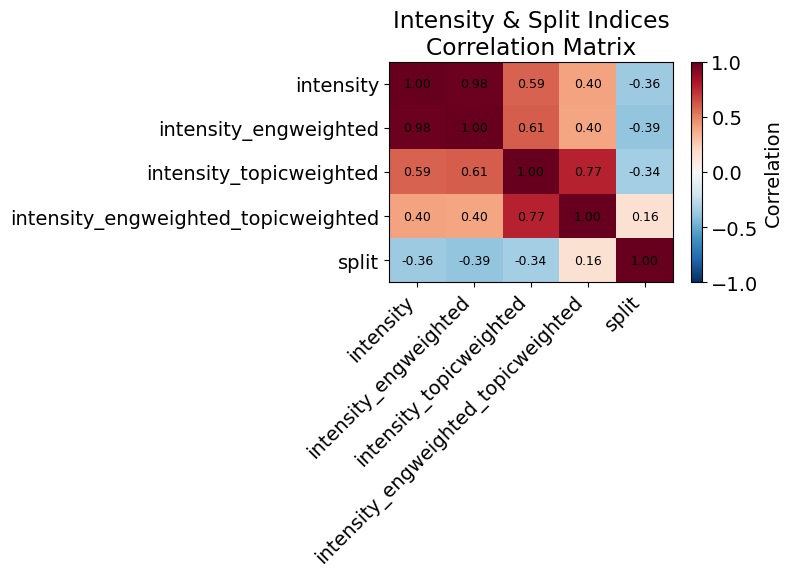

In [5]:
print("\n" + "="*70)
print("Descriptive Statistics")
print("="*70)
stats = compare_index_variants_descriptive(df, all_variants, 'Intensity & Split Indices')

## Time Series Visualization


Time Series Visualization


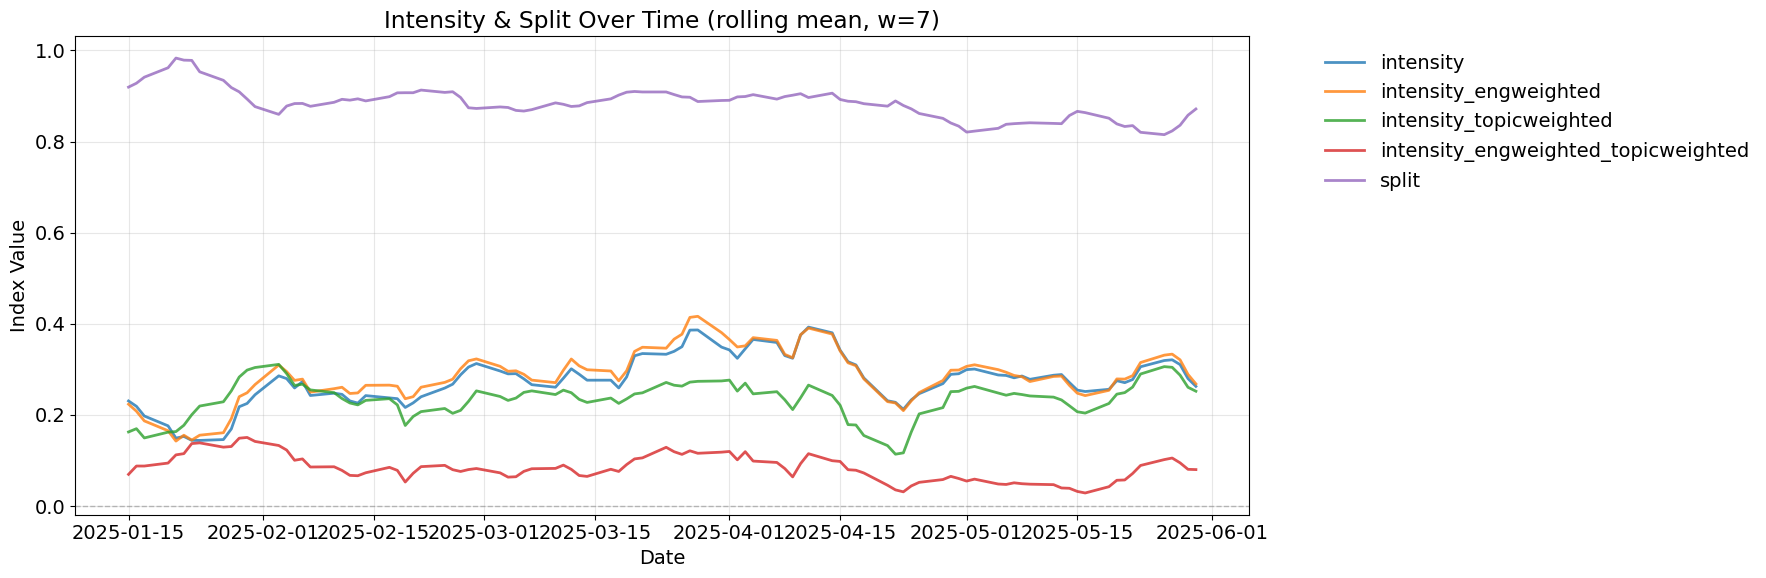

In [6]:
print("\n" + "="*70)
print("Time Series Visualization")
print("="*70)
compare_index_variants_timeseries(df, all_variants, 'Intensity & Split Over Time', rolling_window=7)

## Rolling Correlations with Assets


Rolling Correlations with Assets


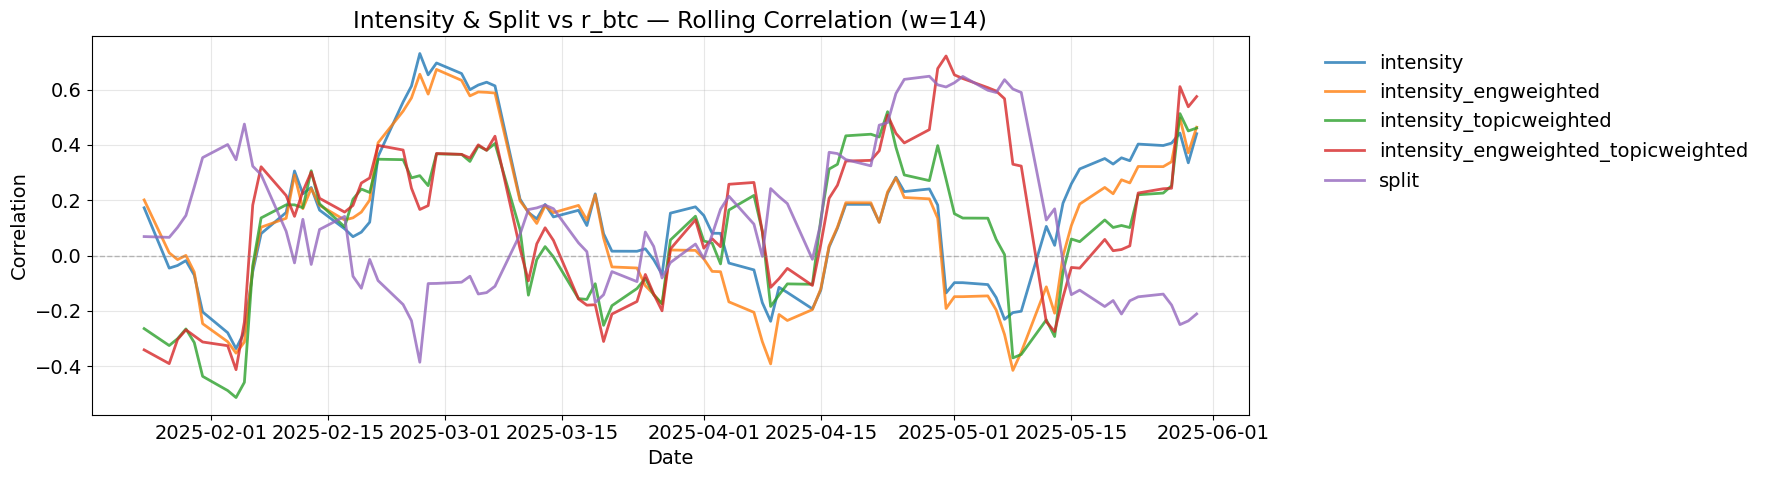

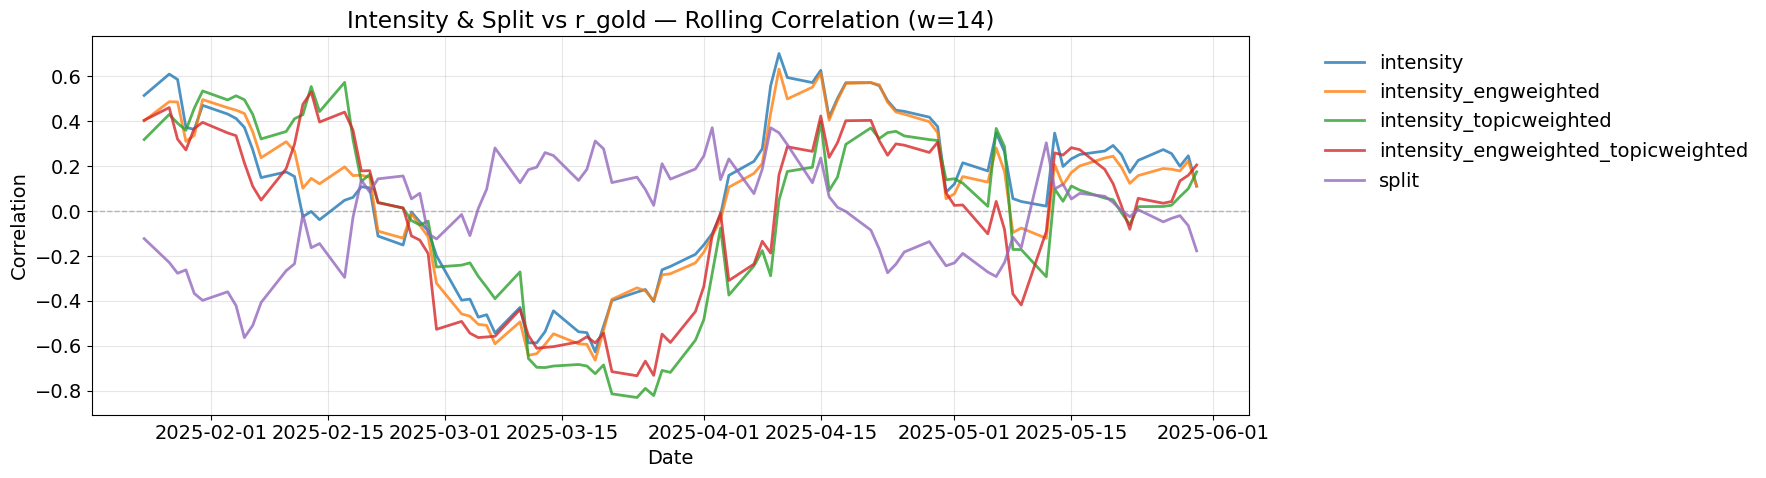

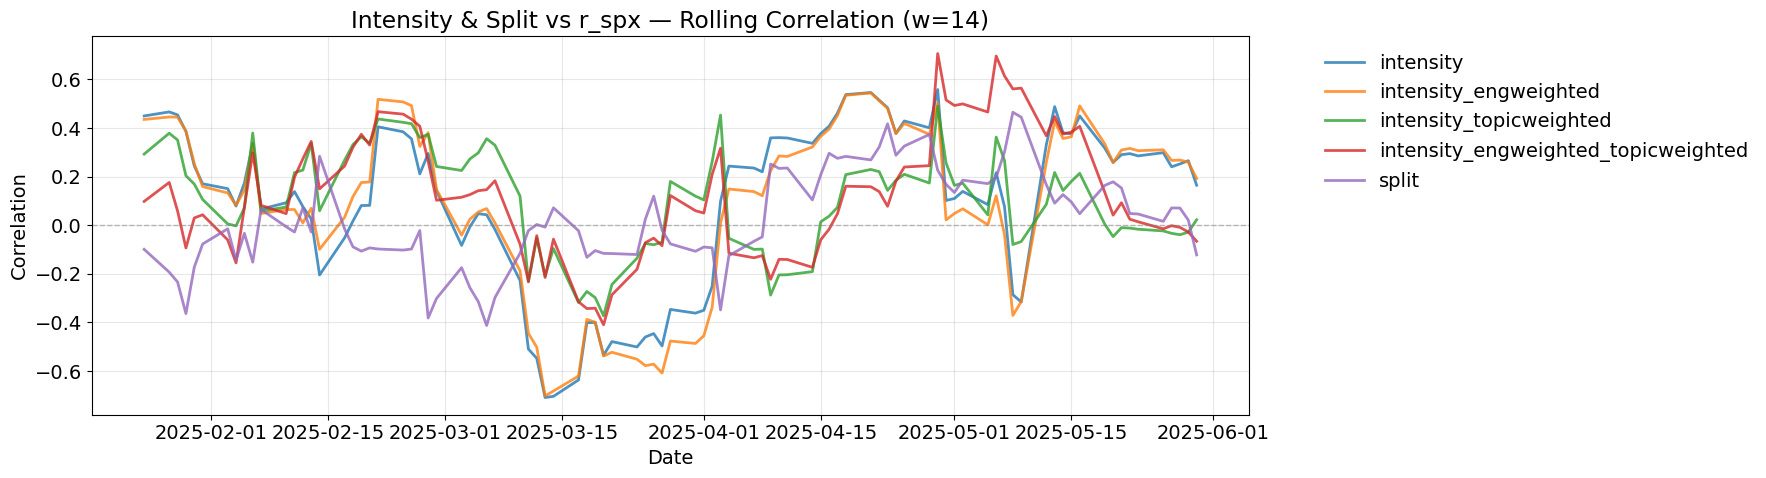

In [7]:
print("\n" + "="*70)
print("Rolling Correlations with Assets")
print("="*70)
compare_variants_vs_assets(df, all_variants, ASSET_COLS, 'Intensity & Split', rolling_window=ROLLING_WINDOW)

## Granger Causality Tests

Test if Intensity/Split variants Granger-cause asset returns using:
- AIC/BIC for optimal lag selection
- Benjamini-Hochberg FDR correction for multiple testing


Granger Causality Tests

GRANGER CAUSALITY TESTS: INTENSITY Variants
Running 15 Granger causality tests...
  Index → Asset causality
  Max lag: 10, IC: AIC
  Multiple testing correction: fdr_bh

✓ Tests complete
  Significant relationships (corrected α=0.05): 0 of 15
  Uncorrected significant (α=0.05): 0

P-values (at optimal lag):


asset,r_btc,r_gold,r_spx
index,,,
intensity,0.311221,0.337814,0.566667
intensity_engweighted,0.258079,0.623357,0.501688
intensity_engweighted_topicweighted,0.721854,0.088755,0.505966
intensity_topicweighted,0.827939,0.323997,0.463335
split,0.225057,0.057624,0.905908



Corrected p-values (fdr_bh):


asset,r_btc,r_gold,r_spx
index,,,
intensity,0.723887,0.723887,0.772728
intensity_engweighted,0.723887,0.779197,0.758949
intensity_engweighted_topicweighted,0.832909,0.665661,0.758949
intensity_topicweighted,0.887077,0.723887,0.758949
split,0.723887,0.665661,0.905908



Significant relationships (α=0.05, corrected):


asset,r_btc,r_gold,r_spx
index,,,
intensity,0,0,0
intensity_engweighted,0,0,0
intensity_engweighted_topicweighted,0,0,0
intensity_topicweighted,0,0,0
split,0,0,0


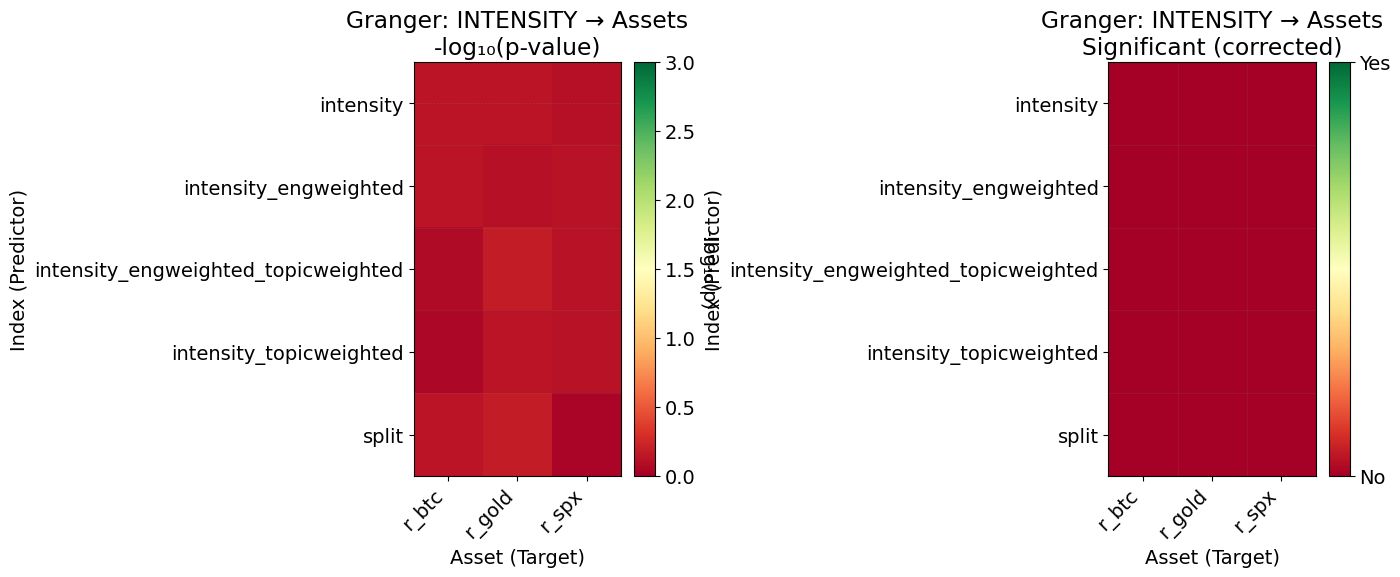

In [8]:
print("\n" + "="*70)
print("Granger Causality Tests")
print("="*70)

pval_mat, pval_corrected, sig_mat = granger_comparison_variants(
    df, all_variants, ASSET_COLS,
    maxlag=MAX_LAG, ic=IC, alpha=ALPHA, correction_method=CORRECTION_METHOD
)

In [9]:
# Variant performance summary
print("\n" + "="*70)
print("Performance Summary")
print("="*70)
performance = summarize_variant_performance(pval_mat, sig_mat, all_variants)


Performance Summary

VARIANT PERFORMANCE SUMMARY


,variant,n_significant,mean_pvalue,min_pvalue
0,intensity,0,0.405234,0.311221
1,intensity_engweighted,0,0.461041,0.258079
2,intensity_topicweighted,0,0.538424,0.323997
3,intensity_engweighted_topicweighted,0,0.438858,0.088755
4,split,0,0.396196,0.057624


In [10]:
# Save results
pval_mat.to_csv(os.path.join(OUTPUT_DIR, "intensity_split_granger_pvalues.csv"))
pval_corrected.to_csv(os.path.join(OUTPUT_DIR, "intensity_split_granger_pvalues_corrected.csv"))
sig_mat.to_csv(os.path.join(OUTPUT_DIR, "intensity_split_granger_significant.csv"))
performance.to_csv(os.path.join(OUTPUT_DIR, "intensity_split_variant_performance.csv"), index=False)

print("\n✓ Results saved to:", OUTPUT_DIR)


✓ Results saved to: ./data/fm_prelim/


## Stationarity Tests

Check if series are stationary (required for valid Granger tests)

In [11]:
print("\n" + "="*70)
print("Stationarity Tests (ADF & KPSS)")
print("="*70)

stationarity_results = []

for var in all_variants:
    if var in df.columns:
        adf = adf_test(df[var])
        kpss_result = kpss_test(df[var])
        
        stationarity_results.append({
            'index': var,
            'adf_stat': adf['statistic'],
            'adf_pval': adf['pvalue'],
            'adf_stationary': '✓' if adf['is_stationary'] else '✗',
            'kpss_stat': kpss_result['statistic'],
            'kpss_pval': kpss_result['pvalue'],
            'kpss_stationary': '✓' if kpss_result['is_stationary'] else '✗'
        })

stationarity_df = pd.DataFrame(stationarity_results)
display(stationarity_df)

print("\nInterpretation:")
print("  ADF: H0=non-stationary. ✓ if p<0.05 (reject H0, series is stationary)")
print("  KPSS: H0=stationary. ✓ if p>0.05 (fail to reject H0, series is stationary)")


Stationarity Tests (ADF & KPSS)


/Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling/modules/finance/exploration/statistical_tests.py:98: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series_clean, regression=regression, nlags=nlags)
/Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling/modules/finance/exploration/statistical_tests.py:98: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series_clean, regression=regression, nlags=nlags)


,index,adf_stat,adf_pval,adf_stationary,kpss_stat,kpss_pval,kpss_stationary
0,intensity,-7.457617,5.459508e-11,✓,0.591343,0.023423,✗
1,intensity_engweighted,-6.418895,1.812158e-08,✓,0.511551,0.039065,✗
2,intensity_topicweighted,-7.397326,7.716633e-11,✓,0.100141,0.100000,✓
3,intensity_engweighted_topicweighted,-8.188227,7.794329e-13,✓,0.426087,0.065911,✓
4,split,-5.715304,7.143778e-07,✓,0.894569,0.010000,✗



Interpretation:
  ADF: H0=non-stationary. ✓ if p<0.05 (reject H0, series is stationary)
  KPSS: H0=stationary. ✓ if p>0.05 (fail to reject H0, series is stationary)


## Bidirectional Granger Tests

Test causality in both directions for best performing variant

In [12]:
print("\n" + "="*70)
print("Bidirectional Granger Tests")
print("="*70)

# Use best performing variant
best_variant = performance.iloc[0]['variant']
print(f"\nBest variant: {best_variant}\n")

for asset in ASSET_COLS:
    print(f"\n{best_variant} ↔ {asset}:")
    print("-" * 70)
    result = bidirectional_granger_test(df, best_variant, asset, maxlag=MAX_LAG, ic=IC)
    display(result)


Bidirectional Granger Tests

Best variant: intensity


intensity ↔ r_btc:
----------------------------------------------------------------------


,direction,optimal_lag,pvalue_at_optimal,min_pvalue,granger_causes,granger_causes_at_optimal
0,intensity → r_btc,1,0.311221,0.221596,False,False
1,r_btc → intensity,1,0.229522,0.073297,False,False



intensity ↔ r_gold:
----------------------------------------------------------------------


,direction,optimal_lag,pvalue_at_optimal,min_pvalue,granger_causes,granger_causes_at_optimal
0,intensity → r_gold,1,0.337814,0.073406,False,False
1,r_gold → intensity,1,0.788989,0.788989,False,False



intensity ↔ r_spx:
----------------------------------------------------------------------


,direction,optimal_lag,pvalue_at_optimal,min_pvalue,granger_causes,granger_causes_at_optimal
0,intensity → r_spx,1,0.566667,0.305558,False,False
1,r_spx → intensity,1,0.001733,0.001733,True,True


## Event Window Analysis

How do Intensity/Split indices behave during major tariff events?

In [13]:
EVENT_WINDOWS = [
    ("Initial Tariff Announcements", "2025-01-20", "2025-01-26"),
    ("Tariffs Postponed", "2025-03-04", "2025-03-06"),
    ("China Retaliation & US Tariffs", "2025-03-10", "2025-03-13"),
    ("Global Tariffs", "2025-04-02", "2025-04-06"),
    ("US-China Tariff Threats", "2025-04-09", "2025-04-12"),
    ("Tariffs Relaxed", "2025-04-27", "2025-05-04"),
    ("Trade Deals", "2025-05-05", "2025-05-14"),
    ("Apple Tariff Threat", "2025-05-20", "2025-05-25"),
]

print("\n" + "="*70)
print("Event Window Analysis")
print("="*70)

event_comparison = event_window_comparison(df, all_variants, EVENT_WINDOWS, pre_days=7, post_days=7)

# Display delta rows only (more compact)
delta_rows = event_comparison[event_comparison['phase'].str.contains('Δ', na=False)]
display(delta_rows)

# Save
event_comparison.to_csv(os.path.join(OUTPUT_DIR, "intensity_split_event_windows.csv"), index=False)
print("\n✓ Event analysis saved")


Event Window Analysis


,event,phase,n,intensity_mean,intensity_std,intensity_engweighted_mean,intensity_engweighted_std,intensity_topicweighted_mean,intensity_topicweighted_std,intensity_engweighted_topicweighted_mean,intensity_engweighted_topicweighted_std,split_mean,split_std
3,Initial Tariff Announcements,Δ during-pre,NaN,-0.020640,NaN,0.015560,NaN,0.086871,NaN,0.029067,NaN,-0.048449,NaN
4,Initial Tariff Announcements,Δ post-during,NaN,0.124809,NaN,0.122658,NaN,0.045275,NaN,-0.019022,NaN,-0.060122,NaN
8,Tariffs Postponed,Δ during-pre,NaN,0.044534,NaN,0.056915,NaN,0.059717,NaN,0.052477,NaN,-0.008011,NaN
9,Tariffs Postponed,Δ post-during,NaN,-0.029891,NaN,-0.026455,NaN,-0.062844,NaN,-0.046600,NaN,0.024562,NaN
13,China Retaliation & US Tariffs,Δ during-pre,NaN,0.007254,NaN,0.007637,NaN,-0.073665,NaN,-0.070036,NaN,0.007435,NaN
14,China Retaliation & US Tariffs,Δ post-during,NaN,0.063106,NaN,0.051846,NaN,0.076009,NaN,0.102385,NaN,0.031570,NaN
18,Global Tariffs,Δ during-pre,NaN,-0.026094,NaN,-0.032350,NaN,-0.065430,NaN,-0.058813,NaN,0.007452,NaN
19,Global Tariffs,Δ post-during,NaN,0.021418,NaN,0.018728,NaN,0.060174,NaN,0.057744,NaN,-0.005632,NaN
23,US-China Tariff Threats,Δ during-pre,NaN,0.093520,NaN,0.090101,NaN,0.086305,NaN,0.096273,NaN,0.007996,NaN
24,US-China Tariff Threats,Δ post-during,NaN,-0.203108,NaN,-0.200987,NaN,-0.239634,NaN,-0.154416,NaN,-0.028141,NaN



✓ Event analysis saved


## Summary

Comprehensive comparison of Intensity and Split indices

In [14]:
print("\n" + "="*70)
print("INTENSITY & SPLIT COMPARISON - SUMMARY")
print("="*70)

print("\n1. INDICES TESTED:")
for i, var in enumerate(all_variants, 1):
    print(f"   {i}. {var}")

print("\n2. CORRELATION WITH ASSETS (mean absolute):")
for var in all_variants:
    if var in df.columns:
        mean_abs_corr = df[[var] + ASSET_COLS].corr().loc[var, ASSET_COLS].abs().mean()
        print(f"   {var:40s}: {mean_abs_corr:.4f}")

print("\n3. GRANGER CAUSALITY (significant relationships after FDR):")
for _, row in performance.iterrows():
    print(f"   {row['variant']:40s}: {int(row['n_significant'])} significant")

print("\n4. BEST PERFORMING INDEX:")
print(f"   {best_variant}")
print(f"   - Significant Granger relationships: {int(performance.iloc[0]['n_significant'])}/{len(ASSET_COLS)}")
print(f"   - Mean p-value: {performance.iloc[0]['mean_pvalue']:.4f}")

print("\n5. KEY INSIGHTS:")
print(f"   - Intensity measures emotion magnitude (may predict volatility)")
print(f"   - Split captures disagreement/consensus among commenters")
print(f"   - High split may indicate uncertainty and information asymmetry")

print("\n" + "="*70)
print("✓ INTENSITY & SPLIT ANALYSIS COMPLETE")
print("="*70)


INTENSITY & SPLIT COMPARISON - SUMMARY

1. INDICES TESTED:
   1. intensity
   2. intensity_engweighted
   3. intensity_topicweighted
   4. intensity_engweighted_topicweighted
   5. split

2. CORRELATION WITH ASSETS (mean absolute):
   intensity                               : 0.2226
   intensity_engweighted                   : 0.1860
   intensity_topicweighted                 : 0.0675
   intensity_engweighted_topicweighted     : 0.0773
   split                                   : 0.1527

3. GRANGER CAUSALITY (significant relationships after FDR):
   intensity                               : 0 significant
   intensity_engweighted                   : 0 significant
   intensity_topicweighted                 : 0 significant
   intensity_engweighted_topicweighted     : 0 significant
   split                                   : 0 significant

4. BEST PERFORMING INDEX:
   intensity
   - Significant Granger relationships: 0/3
   - Mean p-value: 0.4052

5. KEY INSIGHTS:
   - Intensity measures